In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
plt.rcParams.update({'font.size': 20})

import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
### Bathy
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]
### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")

### Datasets
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA_masked")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS_masked",dense=True)
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL_masked")

legend_fs = 15
G_color = "#0D160B"
CMA_color = "#008DD5"
CL_color = "#CB152B"

# Mask all variables that include both ("long", "lat") dimensions
# Keep only the selected box; outside becomes NaN
lon_min = 68.25
lon_max = 70.75
lat_min = -50
lat_max = -48

def apply_spatial_mask(ds, lon_min, lon_max, lat_min, lat_max):
    lon2d, lat2d = xr.broadcast(ds["long"], ds["lat"])
    area_mask = (
        (lon2d >= lon_min) & (lon2d <= lon_max) &
        (lat2d >= lat_min) & (lat2d <= lat_max)
    )

    ds_out = ds.copy()
    for v in ds_out.data_vars:
        if {"long", "lat"}.issubset(ds_out[v].dims):
            ds_out[v] = ds_out[v].where(~area_mask)
    return ds_out

ds_CMA = apply_spatial_mask(ds_CMA, lon_min, lon_max, lat_min, lat_max)
ds_G   = apply_spatial_mask(ds_G, lon_min, lon_max, lat_min, lat_max)
ds_CL  = apply_spatial_mask(ds_CL, lon_min, lon_max, lat_min, lat_max)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


204
204
204


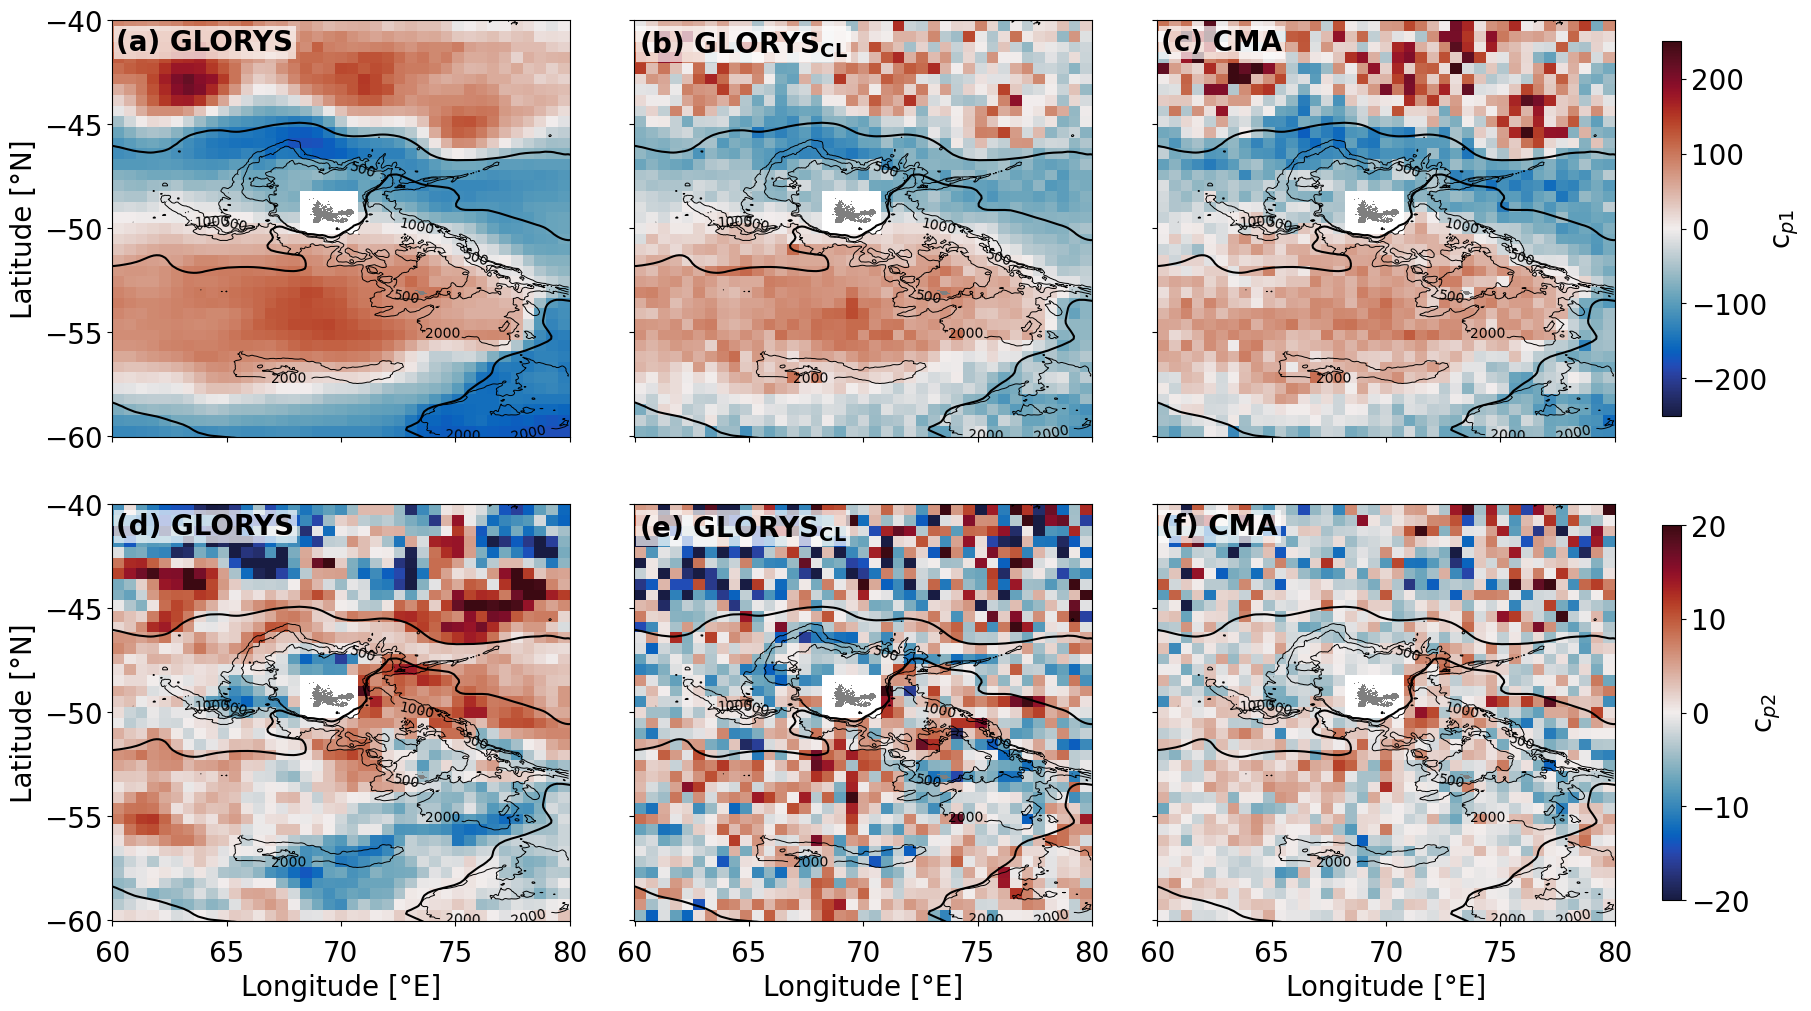

In [ ]:
# 2D lon/lat maps: top row = xi1 (3 datasets), bottom row = xi2 (3 datasets)

vmin_cp1 = -250
vmax_cp1 = 250
vmin_cp2 = -20
vmax_cp2 = 20

datasets = [
    ("GLORYS", ds_G, G_color),
    ("GLORYS_CL", ds_CL, CL_color),
    ("CMA", ds_CMA, CMA_color),
]

def plot_mode_panel(ax, ds_i, label, mode_name, is_bottom=False, is_left=False):
    im = ax.pcolormesh(
        ds_i["long"],
        ds_i["lat"],
        ds_i[mode_name].transpose("lat", "long"),
        shading="auto",
        cmap=cmo.balance,
        vmin=vmin_cp1 if mode_name == "xi1" else vmin_cp2,
        vmax=vmax_cp1 if mode_name == "xi1" else vmax_cp2,
    )

    (elevation / elevation).where(elevation > 0).plot(add_colorbar=False, cmap="gist_yarg", ax=ax)
    CS = (-elevation).plot.contour(levels=(500, 1000, 2000), colors=["black"], linewidths=0.7, ax=ax)
    ax.plot(ds_front.LonSAF.where(ds_front.LatSAF > -50), ds_front.LatSAF.where(ds_front.LatSAF > -50), c="k")
    ax.plot(ds_front.LonPF, ds_front.LatPF, c="k")
    ax.plot(ds_front.LonSACCF, ds_front.LatSACCF, c="k")

    ax.clabel(CS, inline=True, fmt="%1.0f", fontsize=10)
    # ax.set_title(f"{label}")
    ax.set_xticks([60, 65, 70, 75, 80])
    ax.set_yticks([-60, -55, -50, -45, -40])

    if is_bottom:
        ax.set_xlabel("Longitude [°E]")
    else:
        ax.set_xlabel("")

    if is_left:
        ax.set_ylabel("Latitude [°N]")
    else:
        ax.set_ylabel("")

    ax.tick_params(
        axis="x",
        labelbottom=is_bottom
    )
    ax.tick_params(
        axis="y",
        labelleft=is_left
    )

    return im

fig = plt.figure(figsize=(18, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3, hspace=0.08, wspace=0.05)

# Top row: xi1
axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
for j, (ax_i, (label, ds_i, _)) in enumerate(zip(axes_top, datasets)):
    im_top = plot_mode_panel(ax_i, ds_i, label, "xi1", is_bottom=False, is_left=(j == 0))

# Bottom row: xi2
axes_bottom = [fig.add_subplot(gs[1, i], sharex=axes_top[i], sharey=axes_top[i]) for i in range(3)]
for j, (ax_i, (label, ds_i, _)) in enumerate(zip(axes_bottom, datasets)):
    im_bottom = plot_mode_panel(ax_i, ds_i, label, "xi2", is_bottom=True, is_left=(j == 0))

cbar1 = fig.colorbar(im_top, ax=axes_top, orientation="vertical", shrink=0.9, pad=0.02)
cbar1.set_label("c$_{p1}$")

cbar2 = fig.colorbar(im_bottom, ax=axes_bottom, orientation="vertical", shrink=0.9, pad=0.02)
cbar2.set_label("c$_{p2}$")

all_axes = axes_top + axes_bottom
panel_dataset_labels = [label for label, _, _ in datasets] * 2

for i, ax_i in enumerate(all_axes):
    if panel_dataset_labels[i] == "GLORYS_CL":
        panel_dataset_labels[i] = "GLORYS$_{\mathregular{CL}}$"
    ax_i.text(
        0.01, 0.98, f"({chr(97+i)}) {panel_dataset_labels[i]}",
        transform=ax_i.transAxes,
        ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )

for ax_i in axes_bottom:
    ax_i.tick_params(axis="x", which="major", pad=10)

plt.show()
fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_5_cp_maps.png", bbox_inches="tight", dpi=300)